# WEEK 7 - HOMEWORK

In [ ]:
from code_for_hw7 import *
import numpy as np
import modules_disp as disp

A code and data folder that will be useful for doing this lab can be found [**here**](https://introml_oll.odl.mit.edu/cat-soop/_static/6.036/homework/hw07/code_for_hw7.zip). Download this to your computer, or alternatively, use the [**Colab notebook**](https://colab.research.google.com/drive/14pGqETHUQpCCVlkAU4rB_ueh5RjzcqzC).

This homework continues the exploration and implementation of [**neural networks**](https://openlearninglibrary.mit.edu/courses/course-v1:MITx+6.036+1T2019/courseware/Week6/neural_networks/1) as discussed in the notes.

In particular, this homework considers neural networks with multiple layers. Each layer has multiple inputs and outputs, and can be broken down into two parts:

- A **linear** module that implements a linear transformation:

  $$
  z_j = \left(\sum_{i=1}^{m} x_i W_{i,j}\right) + W_{0,j}
  $$

  specified by a weight matrix $W$ and a bias vector $W_0$. The output is:

  $$
  [z_1,\ldots,z_n]^T
  $$

- An **activation** module that applies an activation function to the outputs of the linear module for some activation function $f$, such as **Tanh** or **ReLU** in the hidden layers, or **Softmax** at the output layer. We write the output as:

  $$
  [f(z_1),\ldots,f(z_m)]^T
  $$

  although technically, for some activation functions such as softmax, each output will depend on all the $z_i$, not just one.

We will use the following notation for quantities in a network:

- Inputs to the network are $x_1,\ldots,x_d$.
- Number of layers is $L$.
- There are $m_l$ inputs to layer $l$.
- There are $n_l = m_{l+1}$ outputs from layer $l$.
- The weight matrix for layer $l$ is $W^l$, an $m_l \times n_l$ matrix, and the bias vector (offset) is $W_0^l$, an $n_l \times 1$ vector.
- The outputs of the linear module for layer $l$ are known as **pre-activation** values and denoted $z^l$.
- The activation function at layer $l$ is $f^l(\cdot)$.
- Layer $l$ activations are:

  $$
  a^l =
  [f^l(z_1^l),\ldots,f^l(z_{n_l}^l)]^T
  $$

- The output of the network is:

  $$
  a^L =
  [f^L(z_1^L),\ldots,f^L(z_{n_L}^L)]^T
  $$

- The loss function $\operatorname{Loss}(a,y)$ measures the loss of output values $a$ when the target is $y$.

Here is an illustrative picture:

<div align='center'>
    <img src='../assets/2_network.png' alt='network_img' style = 'border-radius: 10px'/>
</div>

## 1) Backpropagation

The materials for week 6 and week 7 will be helpful here, including the [week6 lecture](https://openlearninglibrary.mit.edu/courses/course-v1\:MITx+6.036+1T2019/courseware/Week6/week6_video/1) and [week7 lecture](https://openlearninglibrary.mit.edu/courses/course-v1\:MITx+6.036+1T2019/courseware/Week7/week7_video/1).

We have seen in the [lecture notes](https://openlearninglibrary.mit.edu/courses/course-v1\:MITx+6.036+1T2019/courseware/Week6/neural_networks/5) how to train multi-layer neural networks as classifiers using stochastic gradient descent (SGD). One of the key steps in the SGD method is the evaluation of the gradient of the loss function with respect to the model parameters. In this problem, you will derive the backpropagation method for a general `L`-layer neural network. We'll exploit the decomposition of the network into *linear* and *activation* modules that we introduced at the start of this homework. Remember that we've defined the shapes of the various quantities at the start of the homework.

- Each linear module has a `forward` method that takes in a column vector of activations `A` (from the previous layer) and returns a column vector `Z` of pre-activations; it can also store its input or output vectors for use by other methods (e.g., for subsequent backpropagation).
- Each activation module has a `forward` method that takes in a column vector of pre-activations `Z` and returns a column vector `A` of activations; it can also store its input or output vectors for use by other methods (e.g., for subsequent backpropagation).
- Each linear module has a `backward` method that takes in a column vector of $\frac{\partial Loss}{\partial Z}$ and returns a column vector of $\frac{\partial Loss}{\partial A}$. This module also computes and stores $\frac{\partial Loss}{\partial W}$ and $\frac{\partial Loss}{\partial W_0}$, the gradients with respect to the weights.
- Each activation module has a `backward` method that takes in a column vector of $\frac{\partial Loss}{\partial A}$ and returns a column vector of $\frac{\partial Loss}{\partial Z}$.

The backpropagation algorithm will consist of:

- Calling the `forward` method of each module in turn, feeding the output of one module as the input to the next; starting with the input values of the network. After this pass, we have a predicted value for the final network output.
- Calling the `backward` method of each module in reverse order, using the returned value from one module as the input value of the previous one. The starting value for the backward method is $\frac{\partial Loss(a^L,y)}{\partial a^L}$, where $a^L$ is the activation of the final layer (computed during the forward pass) and $y$ is the desired output (the label).

### 1.1) Linear Module

The `forward` method, given `A` from the previous layer, implements:

$$
Z=W^TA+W_0
$$

and stores the input `A` to be used by the `backward` method.

Recall that there are `n_l=m_{l+1}` outputs from layer `l`. For layer `l`, `W` is a `m_l\times n_l` matrix, `W_0` is a `n_l\times1` vector, and `A` from the previous layer is a `n_{l-1}\times1` (or `m_l\times1`) vector. Given these shapes, make sure that you understand why the forward equation has `W^T` and not `W`.

The following questions ask for a matrix expression involving any of `A`, `Z`, `dLdA`, `dLdZ`, `W` and `W_0`.

**Enter your answers as Python expressions. You can use `transpose(x)` for transpose of an array, and `x@y` to indicate a matrix product of two arrays. Remember that `x*y` denotes component-wise multiplication.**

The `backward` method, given `dLdZ=\frac{\partial Loss}{\partial Z}` (an `n_l\times1` vector), returns `dLdA=\frac{\partial Loss}{\partial A}` (an `m_l\times1` vector):

$$
\frac{\partial Loss}{\partial A}
=
\frac{\partial Z}{\partial A}
\frac{\partial Loss}{\partial Z}
$$

<div align='center'>
    <img src='../assets/3_1_A.png' alt='3_1_A' style = 'border-radius: 10px'/>
</div>

The `backward` method, given `dLdZ=\frac{\partial Loss}{\partial Z}`, also computes `dLdW` (an $m_l\times n_l$ matrix) and `dLdW0` (an $n_l\times1$ vector), and stores them in the module instance.

<div align='center'>
    <img src='../assets/3_1_A.png' alt='3_1_A' style = 'border-radius: 10px'/>
</div>

<div align='center'>
    <img src='../assets/5_1_C.png' alt='5_1_C' style = 'border-radius: 10px'/>
</div>

We will use dLdW and dLdW0 as the gradient values in SGD.

### 1.2) Activation Module

Activation modules don't have any weights and so they are simpler.

The `forward` method for functions like *tanh* or *sigmoid*, given $Z$, return the function on the vector, componentwise. *Softmax* operates on the whole vector, as described earlier, and will need some special treatment.

The `backward` method, given **dLdA** $= \partial Loss / \partial A$, returns:

$$dLdZ = \frac{\partial Loss}{\partial Z} = \frac{\partial Loss}{\partial A} \frac{\partial A}{\partial Z}$$

In this case, $m^l = n^l$ and the quantities are column vectors of that size.

For $\text{Softmax} = SM(Z)$ at the output layer and assuming that we are using $NLL$ as the $Loss(A, Y)$ function, we have seen that there is a simple form for $\text{\textbf{dLdZ}} = \frac{\partial Loss}{\partial Z}$; namely, it is the prediction error $A - Y$. A similar result holds when using $NLL$ with a sigmoid output activation or a quadratic loss with a linear output activation. Note that for hinge loss with a linear activation, the form of `dLdZ` is different (see the lecture notes on the hinge loss).

## 2) Implementing Neural Networks

**Please watch the lecture videos for this week before attempting this problem.** Additionally, please review the [SGD notes](#).

Although for "real" applications you want to use one of the many packaged implementations of neural networks (we'll start using one of those soon), there is no substitute for implementing one yourself to get an in-depth understanding. Luckily, that is relatively easy to do if we're not too concerned with maximum efficiency.

We'll use the modular implementation that we guided you through in the previous problem, which leads to clean code. The basic framework for SGD training is given below. We can construct a network and train it as follows:

```python
# build a 3-layer network
net = Sequential([Linear(2,3), Tanh(),
                  Linear(3,3), Tanh(),
                  Linear(3,2), SoftMax()])
# train the network on data and labels
net.sgd(X, Y)

In [ ]:
class Module:
    def sgd_step(self, lrate): pass  # For modules w/o weights

#### Linear Modules: ####
Each linear module has a forward method that takes in a batch of activations A (from the previous layer) and returns a batch of pre-activations Z.

Each linear module has a backward method that takes in dLdZ and returns dLdA. This module also computes and stores dLdW and dLdW0, the gradients with respect to the weights.

In [8]:
class Linear(Module):
    def __init__(self, m, n):
        self.m, self.n = (m, n)  # (in size, out size)
        self.W0 = np.zeros([self.n, 1])  # (n x 1)
        self.W = np.random.normal(0, 1.0 * m ** (-.5), [m, n])  # (m x n)

    def forward(self, A):
        self.A = A   # (m x b)  Hint: make sure you understand what b stands for
        return  self.W.T@A + self.W0 # Your code (n x b)

    def backward(self, dLdZ):  # dLdZ is (n x b), uses stored self.A
        self.dLdW = self.A@dLdZ.T       # Your code
        self.dLdW0 = np.sum(dLdZ, axis=1, keepdims=True)      # Your code
        return self.W@dLdZ            # Your code: return dLdA (m x b)

    def sgd_step(self, lrate):  # Gradient descent step
        self.W = self.W - lrate*self.dLdW           # Your code
        self.W0 = self.W0 - lrate*self.dLdW0          # Your code

In [9]:
np.random.seed(0)

# data
X, Y = super_simple_separable()

# module
linear_1 = Linear(2, 3)

#hyperparameters
lrate = 0.005

# test case
# forward
z_1 = linear_1.forward(X)
exp_z_1 =  np.array([[10.41750064, 6.91122168, 20.73366505, 22.8912344],
                     [7.16872235, 3.48998746, 10.46996239, 9.9982611],
                     [-2.07105455, 0.69413716, 2.08241149, 4.84966811]])
unit_test("linear_forward", exp_z_1, z_1)

# backward
dL_dz1 = np.array([[1.69467553e-09, -1.33530535e-06, 0.00000000e+00, -0.00000000e+00],
                                     [-5.24547376e-07, 5.82459519e-04, -3.84805202e-10, 1.47943038e-09],
                                     [-3.47063705e-02, 2.55611604e-01, -1.83538094e-02, 1.11838432e-04]])
exp_dLdX = np.array([[-2.40194628e-02, 1.77064845e-01, -1.27021626e-02, 7.74006953e-05],
                                    [2.39827939e-02, -1.75870737e-01, 1.26832126e-02, -7.72828555e-05]])
dLdX = linear_1.backward(dL_dz1)
unit_test("linear_backward", exp_dLdX, dLdX)

# sgd step
linear_1.sgd_step(lrate)
exp_linear_1_W = np.array([[1.2473734,  0.28294514,  0.68940437],
                           [1.58455079, 1.32055711, -0.69218045]]),
unit_test("linear_sgd_step_W",  exp_linear_1_W,  linear_1.W)

exp_linear_1_W0 = np.array([[6.66805339e-09],
                            [-2.90968033e-06],
                            [-1.01331631e-03]]),
unit_test("linear_sgd_step_W0", exp_linear_1_W0, linear_1.W0)


linear_forward: OK
linear_backward: OK
linear_sgd_step_W: OK
linear_sgd_step_W0: OK


#### Activation functions: ####
Each activation module has a forward method that takes in a batch of pre-activations Z and returns a batch of activations A.

Each activation module has a backward method that takes in dLdA and returns dLdZ, with the exception of SoftMax, where we assume dLdZ is passed in.

#### Tanh: ####

In [11]:
class Tanh(Module):            # Layer activation
    def forward(self, Z):
        self.A = np.tanh(Z)
        return self.A

    def backward(self, dLdA):    # Uses stored self.A
        return dLdA * (1 - (self.A) ** 2)       # Your code: return dLdZ (?, b)

#### ReLU: ####

In [12]:
class ReLU(Module):              # Layer activation
    def forward(self, Z):
        self.A = np.maximum(0, Z)            # Your code: (?, b)
        return self.A

    def backward(self, dLdA):    # uses stored self.A
        return dLdA * (self.A >= 0)      # Your code: return dLdZ (?, b)

#### SoftMax: ####

In [16]:
class SoftMax(Module):           # Output activation
    def forward(self, Z):
        return np.exp(Z)/np.sum(np.exp(Z), axis=0, keepdims=True)              # Your code: (?, b)

    def backward(self, dLdZ):    # Assume that dLdZ is passed in
        return dLdZ

    def class_fun(self, Ypred):  # Return class indices
        return np.argmax(Ypred, axis=0, keepdims=True)              # Your code: (1, b)

#### Loss Functions: ####
Each loss module has a forward method that takes in a batch of predictions Ypred (from the previous layer) and labels Y and returns a scalar loss value.

The NLL module has a backward method that returns dLdZ, the gradient with respect to the preactivation to SoftMax (note: not the activation!), since we are always pairing SoftMax activation with NLL loss

In [14]:
class NLL(Module):       # Loss
    def forward(self, Ypred, Y):
        self.Ypred = Ypred
        self.Y = Y
        return -np.sum(self.Y * np.log(self.Ypred))      # Your code

    def backward(self):  # Use stored self.Ypred, self.Y
        return self.Ypred - self.Y      # Your code

#### Activation and Loss Test Cases: ####
Run Test 1 and Test 2 below and compare your outputs with the expected outputs.


In [17]:
# TEST 1: sgd_test for Tanh activation and SoftMax output
np.random.seed(0)
sgd_test(Sequential([Linear(2,3), Tanh(), Linear(3,2), SoftMax()], NLL()), test_1_values)

linear_1.W: OK
linear_1.W0: OK
linear_2.W: OK
linear_2.W0: OK
z_1: OK
a_1: OK
z_2: OK
a_2: OK
loss: OK
dloss: OK
dL_dz2: OK
dL_da1: OK
dL_dz1: OK
dL_dX: OK
updated_linear_1.W: OK
updated_linear_1.W0: OK
updated_linear_2.W: OK
updated_linear_2.W0: OK


In [22]:
class Sequential:
    def __init__(self, modules, loss):            # List of modules, loss module
        self.modules = modules
        self.loss = loss

    def sgd(self, X, Y, iters=100, lrate=0.005):  # Train
        D, N = X.shape
        sum_loss = 0
        for it in range(iters):
            i = np.random.randint(N)
            Xt = X[:, i:i+1]
            Yt = Y[:, i:i+1]
            Ypred = self.forward(Xt)
            sum_loss += self.loss.forward(Ypred, Yt)
            err = self.loss.backward()
            self.backward(err)
            self.sgd_step(lrate)

    def forward(self, Xt):                        # Compute Ypred
        for m in self.modules: Xt = m.forward(Xt)
        return Xt

    def backward(self, delta):                    # Update dLdW and dLdW0
        # Note reversed list of modules
        for m in self.modules[::-1]: delta = m.backward(delta)

    def sgd_step(self, lrate):                    # Gradient descent step
        for m in self.modules: m.sgd_step(lrate)

    def print_accuracy(self, it, X, Y, cur_loss, every=250):
        # Utility method to print accuracy on full dataset, should
        # improve over time when doing SGD. Also prints current loss,
        # which should decrease over time. Call this on each iteration
        # of SGD!
        if it % every == 1:
            cf = self.modules[-1].class_fun
            acc = np.mean(cf(self.forward(X)) == cf(Y))
            print('Iteration =', it, '	Acc =', acc, '	Loss =', cur_loss)

#### Neural Network / SGD Test Cases: ####
Use Test 3 and Test 4 to help you debug.

-3.46493986 -3.41956036 3.39710997 2.0597278


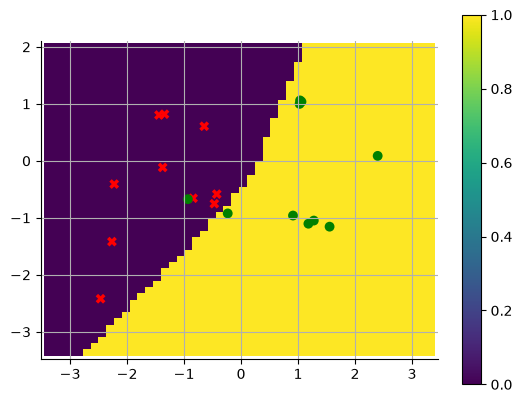

In [23]:
# TEST 3: you should achieve 100% accuracy on the hard dataset (note that we provided plotting code)
X, Y = hard()
nn = Sequential([Linear(2, 10), ReLU(), Linear(10, 10), ReLU(), Linear(10,2), SoftMax()], NLL())
disp.classify(X, Y, nn, it=100000)